In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Paths
label_path = '/home/ec2-user/Jul2025/labels/' # label folder with all the labels
figure_path = '/home/ec2-user/Jul2025/Fig4_Enrichr_Ranked_Prot_Marker_Localization/' # figure output folder

# Orre et al. 3365 markers
orre_marker_path = Path(label_path+'markers.txt') # path to the orre marker file
orre_mcluster_path = Path(label_path+'markers_mclusters.txt') # path to the orre mcluster file

# Uniprot Go markers
uniprot_marker_path = Path(label_path+'uniprot_go_markers_grouped.txt') # path to the uniprot go marker file

In [3]:
# Read in the markers
orre_marker_df = pd.read_csv(orre_marker_path, sep='\t', header=0, index_col=0)
orre_mcluster_df = pd.read_csv(orre_mcluster_path, sep='\t', header=0, index_col=0)
uniprot_marker_df = pd.read_csv(uniprot_marker_path, sep='\t', header=0, index_col=0)

In [4]:
# Combine of the markers for comparison
orre_marker_and_mcluster_df = pd.merge(orre_marker_df, orre_mcluster_df, how='inner', left_index=True, right_index=True)
combined_markers = pd.merge(orre_marker_and_mcluster_df, uniprot_marker_df, how='left', left_index=True, right_index=True, suffixes=('_Orre', '_Uniprot'))

# Drop duplicates
combined_markers = combined_markers[~combined_markers.index.duplicated(keep='first')]

In [5]:
# Create boolean masks for agreement, true disagreement, and missing
is_agreement = (
    combined_markers['Localization_Orre'].notna() &
    combined_markers['Localization_Uniprot'].notna() &
    (combined_markers['Localization_Orre'] == combined_markers['Localization_Uniprot'])
)

is_disagreement = (
    combined_markers['Localization_Orre'].notna() &
    combined_markers['Localization_Uniprot'].notna() &
    (combined_markers['Localization_Orre'] != combined_markers['Localization_Uniprot'])
)

is_missing = (
    combined_markers['Localization_Orre'].isna() |
    combined_markers['Localization_Uniprot'].isna()
)

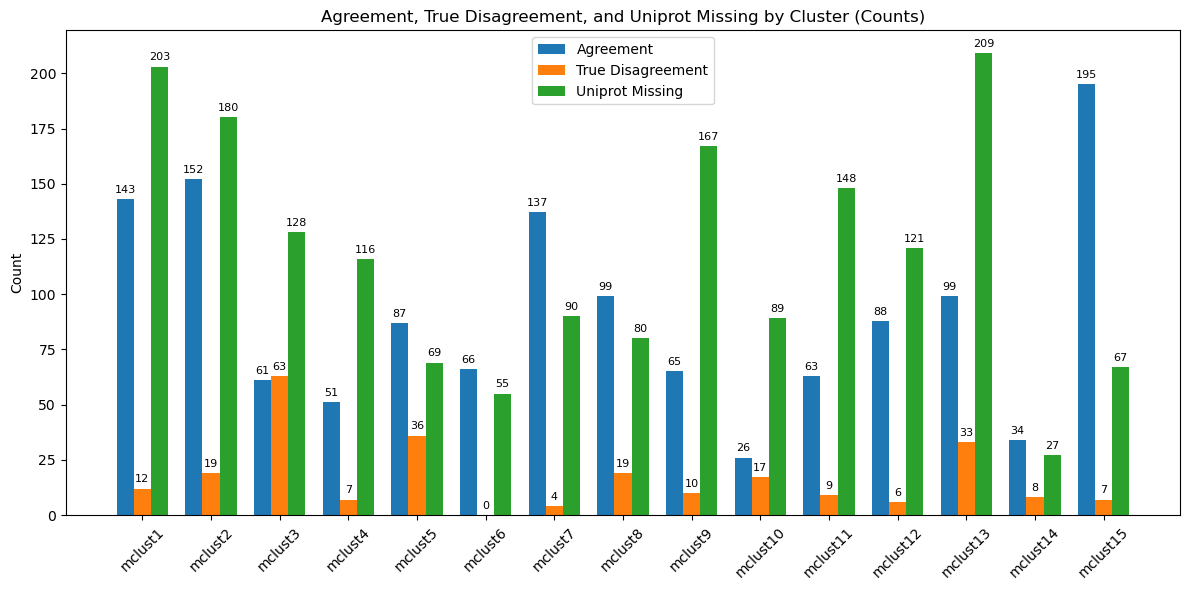

In [6]:
# Plotting the counts of agreement, true disagreement, and missing by cluster
ordered_clusters = list(f'mclust{i}' for i in range(1, 16))

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(ordered_clusters))
width = 0.25

bars1 = ax.bar([i - width for i in x], [
    (combined_markers['Cluster'] == cluster).loc[is_agreement].sum()
    for cluster in ordered_clusters
], width, label='Agreement')

bars2 = ax.bar(x, [
    (combined_markers['Cluster'] == cluster).loc[is_disagreement].sum()
    for cluster in ordered_clusters
], width, label='True Disagreement')

bars3 = ax.bar([i + width for i in x], [
    (combined_markers['Cluster'] == cluster).loc[is_missing].sum()
    for cluster in ordered_clusters
], width, label='Uniprot Missing')

ax.set_xticks(x)
ax.set_xticklabels(ordered_clusters, rotation=45)
ax.set_ylabel('Count')
ax.set_title('Agreement, True Disagreement, and Uniprot Missing by Cluster (Counts)')
ax.legend()

plt.tight_layout()
# Add count labels on top of each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.show()

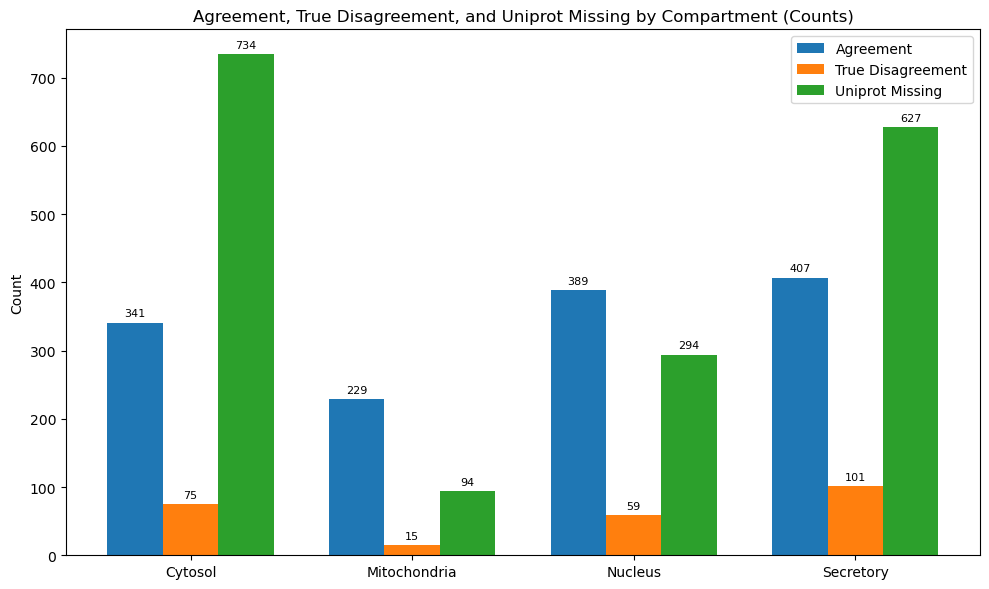

In [ ]:
# Plotting the counts of agreement, true disagreement, and missing by compartment
compartments = ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']
agreement_counts = []
true_disagreement_counts = []
missing_counts = []

for comp in compartments:
    comp_mask = combined_markers['Localization_Orre'] == comp
    agreement_counts.append(is_agreement[comp_mask].sum())
    true_disagreement_counts.append(is_disagreement[comp_mask].sum())
    missing_counts.append(is_missing[comp_mask].sum())

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(compartments))
width = 0.25

bars1 = ax.bar([i - width for i in x], agreement_counts, width, label='Agreement')
bars2 = ax.bar(x, true_disagreement_counts, width, label='True Disagreement')
bars3 = ax.bar([i + width for i in x], missing_counts, width, label='Uniprot Missing')

ax.set_xticks(x)
ax.set_xticklabels(compartments, rotation=0)
ax.set_ylabel('Count')
ax.set_title('Agreement, True Disagreement, and Uniprot Missing by Compartment (Counts)')
ax.legend()

plt.tight_layout()
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

# save figure
plt.savefig(Path(figure_path+'agreement_true_disagreement_by_compartment_counts.pdf'), dpi=300, bbox_inches='tight')

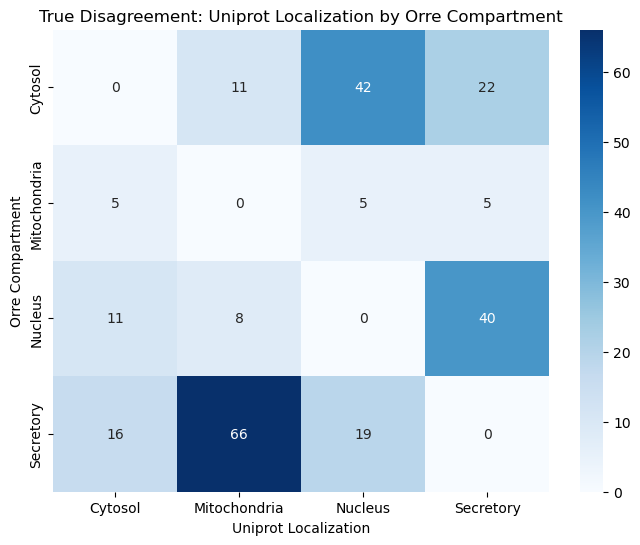

In [8]:
# Prepare true_disagreement_by_compartment dictionary
true_disagreement_by_compartment = {
    comp: combined_markers[is_disagreement & (combined_markers['Localization_Orre'] == comp)]
    for comp in compartments
}

# Prepare data for heatmap: rows are compartments, columns are Uniprot localizations
compartment_labels = compartments
uniprot_labels = compartments

heatmap_matrix = pd.DataFrame(0, index=compartment_labels, columns=uniprot_labels)

for comp in compartments:
    df = true_disagreement_by_compartment[comp]
    # Count Uniprot localizations for disagreement proteins in this compartment
    counts = df['Localization_Uniprot'].value_counts()
    for uniprot_loc in counts.index:
        if uniprot_loc in uniprot_labels:
            heatmap_matrix.loc[comp, uniprot_loc] = counts[uniprot_loc]

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('True Disagreement: Uniprot Localization by Orre Compartment')
plt.ylabel('Orre Compartment')
plt.xlabel('Uniprot Localization')
plt.show()

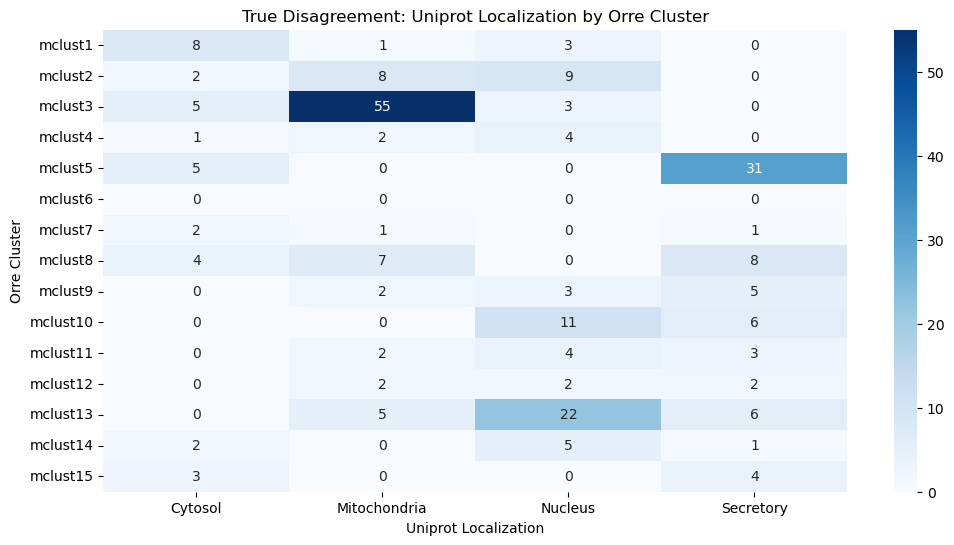

In [ ]:
# Prepare true_disagreement_by_cluster dictionary
true_disagreement_by_cluster = {
    cluster: combined_markers[is_disagreement & (combined_markers['Cluster'] == cluster)]
    for cluster in ordered_clusters
}

# Prepare heatmap matrix: rows=clusters, columns=Uniprot compartments
heatmap_matrix_cluster = pd.DataFrame(0, index=ordered_clusters, columns=compartments)

for cluster in ordered_clusters:
    df = true_disagreement_by_cluster[cluster]
    counts = df['Localization_Uniprot'].value_counts()
    for uniprot_loc in counts.index:
        if uniprot_loc in compartments:
            heatmap_matrix_cluster.loc[cluster, uniprot_loc] = counts[uniprot_loc]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_matrix_cluster, annot=True, fmt='d', cmap='Blues')
plt.title('True Disagreement: Uniprot Localization by Orre Cluster')
plt.ylabel('Orre Cluster')
plt.xlabel('Uniprot Localization')

# Save figure
plt.savefig(Path(figure_path+'true_disagreement_heatmap.pdf'), dpi=300, bbox_inches='tight')
